In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# --- Load dataset ---
# Example format:
# Columns: Species, temp_1, temp_2,..., temp_n
# Rows: Arabian smooth-hound, 0.01527, 0.01518,...
data = pd.read_csv("shark_dataset.csv")

# --- Features = Fluorescence values, Label = Species ---
X_raw = data.drop(columns=["Species"])
y = data["Species"]

# --- Drop species with <2 samples to allow stratification ---
counts = y.value_counts()
valid_classes = counts[counts >= 2].index
mask = y.isin(valid_classes)
X_raw = X_raw[mask]
y = y[mask]


In [ ]:
# --- Feature engineering ---

from scipy.integrate import simpson

def feature_engineering(df):
    features = pd.DataFrame()
    temps = df.columns.astype(float)

    features['max'] = df.max(axis=1)
    features['min'] = df.min(axis=1)
    features['mean'] = df.mean(axis=1)
    features['std'] = df.std(axis=1)
    
    features['auc'] = df.apply(lambda row: simpson(row, temps), axis=1)
    features['centroid'] = df.apply(lambda row: np.sum(row*temps)/np.sum(row), axis=1)
    
    features['temp_peak'] = df.apply(lambda row: temps[np.argmax(row)], axis=1)
    features['fwhm'] = df.apply(lambda row: np.sum(row > 0.5*row.max()), axis=1)
    features['rise_time'] = df.apply(lambda row: np.argmax(row), axis=1)
    features['decay_time'] = df.apply(lambda row: len(row) - np.argmax(row[::-1]), axis=1)
    
    features['auc_left'] = df.apply(lambda row: simpson(row[:np.argmax(row)+1], temps[:np.argmax(row)+1]), axis=1)
    features['auc_right'] = df.apply(lambda row: simpson(row[np.argmax(row):], temps[np.argmax(row):]), axis=1)
    
    features['asymmetry'] = features['auc_left'] / (features['auc_right'] + 1e-8)
    return features

X_features = feature_engineering(X_raw)

In [107]:
# --- Train/test split with stratification (keeps species balanced across sets) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,   # number of trees
    max_depth=None,     # fully expanded trees
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

rf.fit(X_train, y_train)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# --- Hyperparameter tuning ---
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# --- Best Random Forest ---
best_rf = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)
print("Best cross-val score:", grid_search.best_score_)


# --- Train best model on full train set ---
best_rf.fit(X_train, y_train)


c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-val score: 0.8173076923076923


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [110]:
# --- Predictions on test set ---
sample_idx = np.random.choice(X_test.index, size=5, replace=False)
for idx in sample_idx:
    probs = best_rf.predict_proba([X_test.loc[idx]])[0]
    sorted_idx = np.argsort(probs)[::-1]
    
    print(f"Row {idx} | True: {y_test.loc[idx]} | Pred: {best_rf.classes_[sorted_idx[0]]} ({probs[sorted_idx[0]]*100:.1f}%)")
    for i in sorted_idx[:5]:
        print(f"  {best_rf.classes_[i]:<25} {probs[i]*100:.3f}%")
    print()

Row 173 | True: Common thresher shark | Pred: Sandtiger shark (46.5%)
  Sandtiger shark           46.500%
  Common thresher shark     39.000%
  Hooktooth shark           6.500%
  Pelagic thresher shark    5.000%
  Thornback ray             1.500%

Row 355 | True: Milk shark | Pred: Blacktip shark (25.5%)
  Blacktip shark            25.500%
  Porbeagle shark           15.500%
  Milk shark                11.000%
  Silvertip shark           7.500%
  Sandbar shark             6.500%

Row 17 | True: Blackchin guitarfish | Pred: Blackchin guitarfish (81.0%)
  Blackchin guitarfish      81.000%
  Halavi guitarfish         14.000%
  Finetooth shark           1.500%
  Tiger shark               1.000%
  Pacific guitarfish        0.500%

Row 298 | True: Hooktooth shark | Pred: Common thresher shark (42.5%)
  Common thresher shark     42.500%
  Hooktooth shark           33.500%
  Sandtiger shark           8.000%
  Pelagic thresher shark    6.000%
  Lemon shark               2.500%

Row 254 | True: 

c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\skl

In [112]:
# --- Evaluation ---
y_test_pred = best_rf.predict(X_test)
print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Test Accuracy: 0.8702290076335878

Classification Report:
                             precision    recall  f1-score   support

      Arabian smooth-hound       1.00      1.00      1.00         1
  Atlantic Sharpnose shark       1.00      1.00      1.00         1
      Blackchin guitarfish       0.67      1.00      0.80         2
           Blacknose shark       1.00      1.00      1.00         1
 Blackspotted smooth-hound       0.00      0.00      0.00         1
       Blacktip reef shark       1.00      1.00      1.00         1
            Blacktip shark       0.75      1.00      0.86         6
                Blue shark       0.86      0.86      0.86         7
          Bonnethead shark       1.00      1.00      1.00         1
       Bowmouth guitarfish       1.00      1.00      1.00         1
  Brownbanded bamboo shark       1.00      0.50      0.67         2
                Bull shark       1.00      1.00      1.00         6
      Caribbean reef shark       1.00      1.00      1.

c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
# --- Confusion matrix for species-level performance ---
cm = confusion_matrix(y_test, y_test_pred, labels=best_rf.classes_)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()

In [113]:
# --- Feature importance ---
importances = pd.Series(best_rf.feature_importances_, index=X_features.columns)
print("\nTop 10 Important Features:\n", importances.nlargest(10))


Top 10 Important Features:
 fwhm          0.170025
rise_time     0.103116
temp_peak     0.102982
decay_time    0.099480
asymmetry     0.093537
std           0.079233
max           0.077552
centroid      0.065154
auc_right     0.057456
auc_left      0.044863
dtype: float64


c:\Users\thepa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Cross-validation accuracies: [0.83969466 0.85384615 0.83076923 0.82307692 0.80769231]
Mean accuracy: 0.8310158543746329


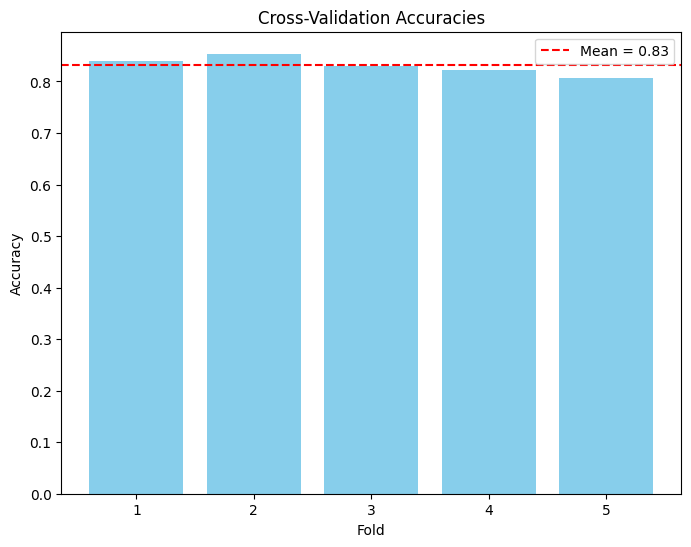

In [114]:
# --- Stratified K-Fold Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_rf, X_features, y, cv=cv, scoring='accuracy')

print("Cross-validation accuracies:", scores)
print("Mean accuracy:", scores.mean())
plt.figure(figsize=(8,6))
plt.bar(range(1, len(scores)+1), scores, color="skyblue")
plt.axhline(np.mean(scores), color="red", linestyle="--", label=f"Mean = {scores.mean():.2f}")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Accuracies")
plt.legend()
plt.show()

In [ ]:
# --- Per-class precision, recall, and F1 ---
report = classification_report(y_test, y_test_pred, output_dict=True)
df = pd.DataFrame(report).transpose().drop(["accuracy", "macro avg", "weighted avg"])
precision = df["precision"]
recall = df["recall"]
f1 = df["f1-score"]

# Plot precision
plt.figure(figsize=(12,6))
precision.plot(kind="bar", color="skyblue")
plt.title("Per-Class Precision")
plt.ylabel("Precision")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot recall
plt.figure(figsize=(12,6))
recall.plot(kind="bar", color="lightgreen")
plt.title("Per-Class Recall")
plt.ylabel("Recall")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot F1 score
plt.figure(figsize=(12,6))
f1.plot(kind="bar", color="salmon")
plt.title("Per-Class F1 Score")
plt.ylabel("F1 Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()